In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                             precision_score, recall_score, accuracy_score,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve, brier_score_loss)


from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier


import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, Model
from tensorflow.keras.optimizers import Adam



In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# Loading the 3 DSs that I prepared in Prepro.ipynb.
df_test = pd.read_csv('test.csv')
df_val = pd.read_csv('val.csv')
df_train = pd.read_csv('train.csv')
df_train.head()

,date,Temperature,Humidity,Light,CO2,Occupancy,tod_sin,tod_cos,weekend
0,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,1,-0.999229,-0.039260,0
1,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,1,-0.999388,-0.034972,0
2,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,1,-0.999534,-0.030539,0
3,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,1,-0.999657,-0.026177,0
4,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,1,-0.999762,-0.021815,0


In [4]:
print(f"Train: {df_train['Occupancy'].mean():.2%}")
print(f"Val: {df_val['Occupancy'].mean():.2%}")
print(f"Test:{df_test['Occupancy'].mean():.2%}")

Train: 20.53%
Val: 25.40%
Test:21.01%


In [5]:
# I scale only the  4 columns (temperature, humidity, light, co2) because they have different ranges.
# weekend is already 0/1, tod sin and tod cos are already in [-1, 1] from the cyclic encoding.

continuuous_columns = ['Temperature',"Humidity", 'Light',"CO2", 'weekend', 'tod_sin',"tod_cos"]

X_train, y_train = df_train[continuuous_columns].values, df_train['Occupancy'].values.astype(int)
X_val, y_val = df_val[continuuous_columns].values, df_val["Occupancy"].values.astype(int)
X_test, y_test = df_test[continuuous_columns].values, df_test['Occupancy'].values.astype(int)

scaler = StandardScaler()
X_train[:, :4] = scaler.fit_transform(X_train[:, :4])
X_val[:, :4]= scaler.transform(X_val[:, :4])
X_test[:, :4] = scaler.transform(X_test[:, :4])

print('Scaled train:', X_train.shape)

Scaled train: (6970, 7)


### Baselines Before CNN

In [ ]:
# Before building a CNN, I am gonna build baselines to know if the CNN is actually better.

models = {'Dummy classifier': DummyClassifier(strategy='most_frequent'),
          'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
          "Random Forest": RandomForestClassifier(n_estimators=200,random_state=42, n_jobs=-1),
          'Gradient Boosting': GradientBoostingClassifier(n_estimators=300, learning_rate=0.1,max_depth=5, random_state=42)}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    rows.append({"Model": name,
                 'Val_accuracy': accuracy_score(y_val, pred_val), 'Val_f1': f1_score(y_val, pred_val, zero_division=0),
                 'Test_accuracy': accuracy_score(y_test, pred_test), 'Test_f1': f1_score(y_test, pred_test, zero_division=0)})
    
results_baseline = pd.DataFrame(rows)
print(results_baseline.round(4))
# Random forest is so good on test, the CNN model has to get a better score than that to be worth it
# Legistic regression got good scores on val but not on test, I think this is because val ds and test ds have different distributions.

                 Model  Val_accuracy  Val_f1  Test_accuracy  Test_f1
0     Dummy classifier        0.7460  0.0000         0.7899   0.0000
1  Logistic Regression        0.9625  0.9247         0.8839   0.7508
2        Random Forest        0.9983  0.9967         0.9809   0.9559
3    Gradient Boosting        0.9395  0.8936         0.9027   0.8063


In [7]:
# I am gonna create  function slide windows

def window_time(X, y, window_size):
    X_window = np.array([X[end-window_size + 1:end + 1] for end in range(window_size-1, len(X))])
    y_window =y[window_size - 1:]
    return X_window, y_window

X_window, y_window = window_time(X_train, y_train,30)
print(X_window.shape, y_window.shape)

(6941, 30, 7) (6941,)


In [8]:
# Here I will build a simple CNN to compare windows sizes and get a best one. 
def build_cnn(window_size, n_features):
    model = tf.keras.Sequential([
         layers.Input(shape=(window_size, n_features)),
         layers.Conv1D(32, 3, padding='causal', activation='relu'),
         layers.Conv1D(64, 3, padding='causal', activation='relu'),
         layers.GlobalAveragePooling1D(),
         layers.Dense(32, activation="relu"),
         layers.Dropout(0.3),
         layers.Dense(1, activation='sigmoid')])

    model.compile(optimizer='adam', loss='binary_crossentropy',metrics=[tf.keras.metrics.AUC(name='auc')])   
    return model

In [ ]:
# I try 3 window sizes: 15, 30, 60.  I compare them on validation average precision.
rows = []
for ws in [15, 30, 60]:
    X_window_train, y_window_train = window_time(X_train, y_train, ws)
    X_window_val, y_window_val = window_time(X_val, y_val, ws)

    negative,positive = np.bincount(y_window_train.astype(int))
    Class_Weight ={0: 1.0, 1:negative/positive}

    model = build_cnn(ws, X_window_train.shape[2])
    early_stop = callbacks.EarlyStopping(monitor='val_auc',mode='max', patience=5,restore_best_weights=True,verbose=0)

    model.fit( X_window_train, y_window_train, validation_data=(X_window_val, y_window_val), epochs=30,
               batch_size=64,class_weight=Class_Weight, callbacks=[early_stop], verbose=0)

    val_prob = model.predict(X_window_val, verbose=0).ravel()
    val_pred =(val_prob >= 0.5).astype(int)

    rows.append({'window': ws, 'AUC': roc_auc_score(y_window_val, val_prob),
                 "Average_precision": average_precision_score(y_window_val,val_prob),
                 'F1_0.5': f1_score(y_window_val, val_pred, zero_division=0),})

windows_df = pd.DataFrame(rows).sort_values("Average_precision", ascending=False).reset_index(drop=True)
print(windows_df.round(4))

best_window = int(windows_df.loc[0, 'window'])

# All 3 windows got close AP scores. 
# 15 got higher score which make sense,  shorter window 
# for 15, the auc is perfect, this is not surprising because light is key solve for occupancy.
# Having 15 of temporal context, the signal is clean and val ds is small
# Source: https://keras.io/examples/timeseries/timeseries_classification_from_scratch/
# I used QWEN for debugging.

   window     AUC  Average_precision  F1_0.5
0      15  1.0000             0.9999  0.9912
1      30  0.9992             0.9976  0.9669
2      60  0.9946             0.9810  0.8994


## Building CNN model

In [ ]:
# Now I can use the best window size. 

WINDOW = int(best_window)
X_window_train, y_window_train= window_time(X_train, y_train, WINDOW)
X_window_val,y_window_val= window_time(X_val, y_val, WINDOW)
X_window_test, y_window_test =window_time(X_test, y_test, WINDOW)

# class weight must be from the actual training windows, not from the search loop
negative, positive = np.bincount(y_window_train.astype(int))
Class_Weight = {0: 1.0, 1: negative / positive}

In [11]:
# The final model is deeper than the search model in previous cell

def build_final(windows_size, input_features):
    inp = layers.Input(shape=(windows_size, input_features))
    x = layers.Conv1D(64, 3, padding='causal', dilation_rate=1)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv1D(64, 3, padding='causal', dilation_rate=2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv1D(128, 3, padding="causal", dilation_rate=4)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(1, activation="sigmoid")(x)
    return Model(inp, x)

model = build_final(WINDOW, X_window_train.shape[2])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 15, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 15, 64)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 15, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,809 (186.75 KB)

 Trainable params: 47,297 (184.75 KB)

 Non-trainable params: 512 (2.00 KB)

In [12]:
# Compiling  with BCE loss 

model.compile( optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy",
    metrics=["accuracy",tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='prec'),
             tf.keras.metrics.Recall(name='rec')])
        
early_stop = callbacks.EarlyStopping(monitor="val_auc", mode='max', patience=10, restore_best_weights=True, verbose=1)
schedule_learning = callbacks.ReduceLROnPlateau(monitor='val_auc',mode='max', patience=5,factor=0.5, min_lr=0.00001, verbose=1)

history = model.fit(X_window_train, y_window_train, validation_data=(X_window_val, y_window_val),
                    epochs=80, batch_size=64,class_weight= Class_Weight,callbacks=[early_stop, schedule_learning],verbose=1)
# sources:
# https://www.tensorflow.org/api_docs/python/tf/keras/metrics/AUC

Epoch 1/80
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9619 - auc: 0.9924 - loss: 0.1588 - prec: 0.8504 - rec: 0.9866 - val_accuracy: 0.9888 - val_auc: 0.9989 - val_loss: 0.1087 - val_prec: 0.9788 - val_rec: 0.9754 - learning_rate: 0.0010
Epoch 2/80
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9812 - auc: 0.9962 - loss: 0.0868 - prec: 0.9219 - rec: 0.9915 - val_accuracy: 0.9948 - val_auc: 0.9998 - val_loss: 0.0287 - val_prec: 0.9894 - val_rec: 0.9894 - learning_rate: 0.0010
Epoch 3/80
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9842 - auc: 0.9974 - loss: 0.0713 - prec: 0.9325 - rec: 0.9944 - val_accuracy: 0.9957 - val_auc: 0.9991 - val_loss: 0.0233 - val_prec: 0.9895 - val_rec: 0.9930 - learning_rate: 0.0010
Epoch 4/80
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9843 - auc: 0.9974 - loss: 0.0661 - prec: 0.9343 - rec: 0.9929 - val_accuracy: 0.9940 - val_auc: 0.9983 - val_loss: 0.0375 - val_prec: 0.9826 - val_rec: 0.9930 - learning_rate: 0.0010


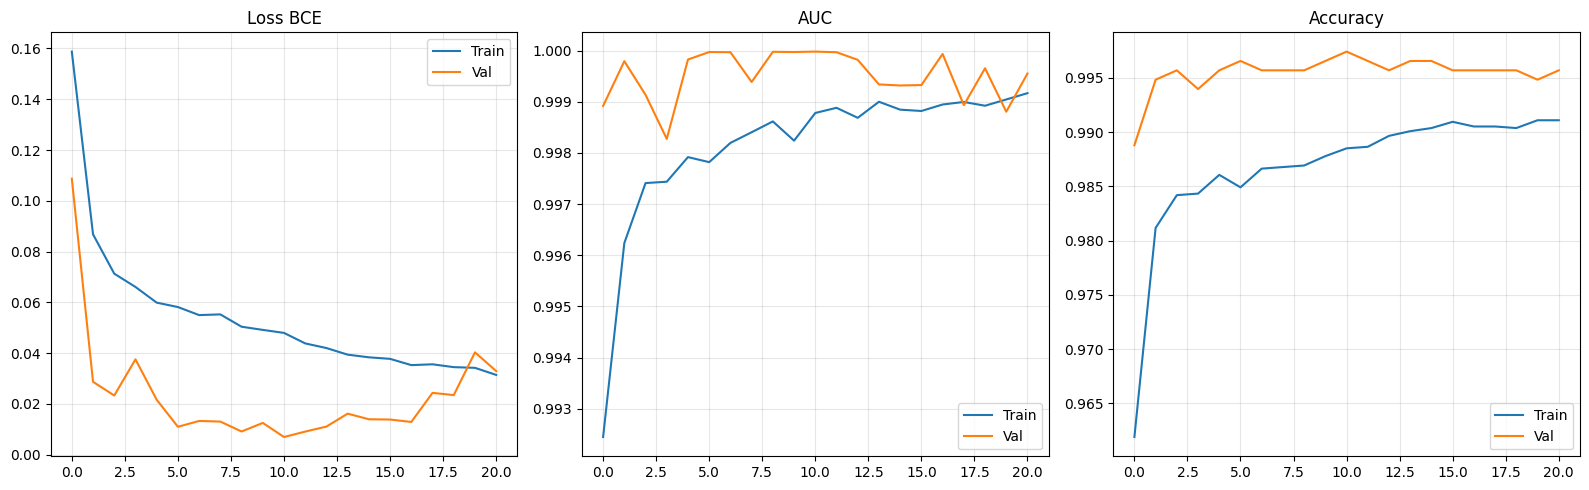

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title in zip(axes, ['loss', 'auc', "accuracy"], ['Loss BCE', 'AUC', 'Accuracy']):
    ax.plot(history.history[metric],label='Train')
    ax.plot(history.history[f'val_{metric}'],label='Val')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# train loss drops smoothly, but val loss is noisy, there are many possibillities:
# I have small val ds or class weight. 

### Evaluation and Threshold Analysis

In [14]:
# Let me test the model on the test ds and find the best threshold for F1 score.
y_prob_val = model.predict(X_window_val, verbose=0).ravel()
precision, recall, threshold = precision_recall_curve(y_window_val, y_prob_val)
f1_scores = 2*(precision*recall)/(precision + recall + 0.00000001)
best_score= np.argmax(f1_scores)
best_threshold = threshold[best_score]

print(f"Best threshold: {best_threshold:.3f} with f1 score: {f1_scores[best_score]:.3f}")
print(f'Precision: {precision[best_score]:.3f}, Recall: {recall[best_score]:.3f}')

# Default threshold got better score, this is because of  the weight class. It is high.
# Always the tunning is not helpful, I just wanted to experiment with it.  

# Source: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.FixedThresholdClassifier.html#sklearn.model_selection.FixedThresholdClassifier
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.fbeta_score.html#sklearn.metrics.fbeta_score

Best threshold: 0.920 with f1 score: 0.996
Precision: 1.000, Recall: 0.993


In [15]:
# in this cell. I am gonna compare the optimized threshold  vs default which always 0.5. 
# threshold was already found in previous cell.
y_prob_test = model.predict(X_window_test, verbose=0).ravel()

y_optimzed = (y_prob_test >= best_threshold).astype(int)
y_defualt = (y_prob_test >= 0.5).astype(int)

print("Optimized threshold")
confucion_matrix_optimized = confusion_matrix(y_window_test, y_optimzed)
print(confucion_matrix_optimized)
print(classification_report(y_window_test, y_optimzed, target_names=['Unoccupied', 'Occupied'], digits=3))

print('\nDefault threshold')
confucion_matrix_default = confusion_matrix(y_window_test, y_defualt)
print(confucion_matrix_default)
print(classification_report(y_window_test, y_defualt, target_names=["Unoccupied", 'Occupied'], digits=3))

# As I mentioned before, the default threshold has score, always tunning does not help.
# I just wanted to experience.  

Optimized threshold
[[7689   14]
 [ 828 1207]]
              precision    recall  f1-score   support

  Unoccupied      0.903     0.998     0.948      7703
    Occupied      0.989     0.593     0.741      2035

    accuracy                          0.914      9738
   macro avg      0.946     0.796     0.845      9738
weighted avg      0.921     0.914     0.905      9738


Default threshold
[[7669   34]
 [ 197 1838]]
              precision    recall  f1-score   support

  Unoccupied      0.975     0.996     0.985      7703
    Occupied      0.982     0.903     0.941      2035

    accuracy                          0.976      9738
   macro avg      0.978     0.949     0.963      9738
weighted avg      0.976     0.976     0.976      9738



### Feature Importance & Naive Baseline

In [16]:
# Implortance of features
Gradient_Boost = GradientBoostingClassifier(n_estimators=500, max_depth=6,
                                            learning_rate=0.05, subsample=0.8, random_state=42).fit(X_train, y_train)
importances = pd.Series(Gradient_Boost.feature_importances_, index=continuuous_columns).sort_values(ascending=False)
print("Feature importances:")
print(importances.round(3))
# It make sense that light is the most important feature.

Feature importances:
Light          0.921
tod_sin        0.021
CO2            0.019
Temperature    0.016
tod_cos        0.015
Humidity       0.005
weekend        0.003
dtype: float64


In [21]:
# Here, I take the light from test ds. 
# to not get error,  the window must be shiffted.
light_test = df_test['Light'].values[WINDOW-1:]
naive_predicted = (light_test >0).astype(int)

print(f"Light above 0: F1={f1_score(y_window_test, naive_predicted):.4f}")
print(f"Random forest with all features: F1={results_baseline.loc[results_baseline['Model']=='Random Forest', 'Test_f1'].values[0]:.4f}")
print(f'CNN:F1={f1_score(y_window_test, y_optimzed):.4f}')
# light is very strong feature, but I can see a big jump from 70 to 95
# so other features are important too. 

Light above 0: F1=0.7043
Random forest with all features: F1=0.9559
CNN:F1=0.7414


### Probability Calibration

Brier score: 0.0181


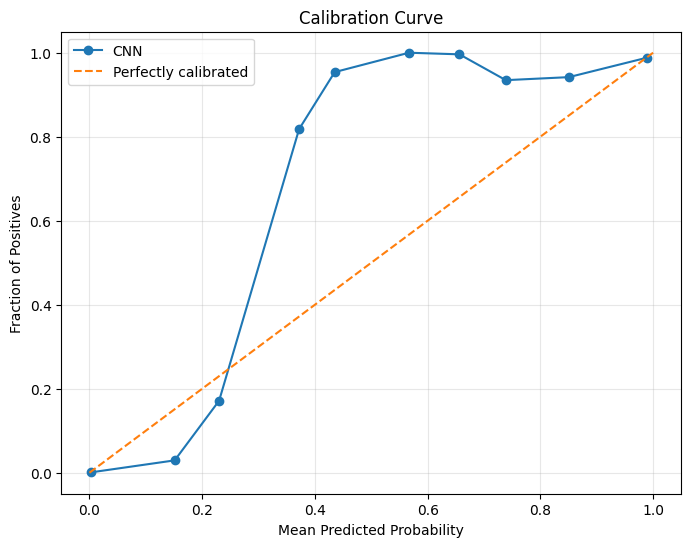

In [18]:
# I wanna to see if the predicted probability of 0.7 actually means 70% chance of occupied

fraction_posistive, mean_prediction = calibration_curve(y_window_test, y_prob_test, n_bins=10, strategy='uniform')
brier = brier_score_loss(y_window_test, y_prob_test)

print(f"Brier score: {brier:.4f}")
plt.figure(figsize=(8, 6))
plt.plot(mean_prediction, fraction_posistive, marker='o', label='CNN')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.title('Calibration Curve')
plt.xlabel("Mean Predicted Probability")
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Brier score is low which is good 
# The curve shows that the model is overconfident , this is because of the class weight
# it shifts the probability distribution

# Source: https://scikit-learn.org/stable/modules/generated/sklearn.calibration.CalibrationDisplay.html#sklearn.calibration.CalibrationDisplay.from_predictions
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html